# Smart Energy Optimizer — Data Exploration and Forecasting Baselines

Understand the local data, select a practical panel, inspect temporal patterns and establish a forecasting reference.
**Scope:** preparation, training-only EDA and seasonal naive baselines. Weather stays separate.

## 1. Inspect the local files

Start here: the notebook shows the reasoning and transformations directly, step by step.
The Python files in `src/` are reusable versions of this logic for scripts and tests.
We do not import them here.

Run all cells from top to bottom. The raw files are in `archive/`; this notebook builds the small development panel from them.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW = ROOT / 'archive'
PROCESSED = ROOT / 'data/processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:.4f}'.format

In [2]:
# Read headers and file sizes, without loading the full consumption archive.
files = []
for path in sorted(RAW.rglob('*')):
    if path.is_file():
        columns = []
        if path.suffix == '.csv':
            columns = list(pd.read_csv(path, nrows=0, encoding='latin-1').columns)
        files.append({'path': str(path.relative_to(ROOT)), 'bytes': path.stat().st_size,
                      'format': path.suffix, 'columns': ' | '.join(columns)})

inventory = pd.DataFrame(files)
inventory.to_csv(REPORTS / 'raw_file_inventory.csv', index=False)
inventory['folder'] = inventory['path'].map(lambda path: str(Path(path).parent))
file_summary = inventory.groupby('folder').agg(files=('path', 'size'), bytes=('bytes', 'sum'))
file_summary['size_MiB'] = file_summary['bytes'] / 2**20
display(file_summary[['files', 'size_MiB']].round(1))

,files,size_MiB
folder,,
archive,7,338.2000
archive/daily_dataset/daily_dataset,112,357.1000
archive/halfhourly_dataset/halfhourly_dataset,112,7501.3000
archive/hhblock_dataset/hhblock_dataset,112,1593.8000


| Files | Priority | Description |
|---|---|---|
| `halfhourly_dataset/` | Needed now | Electricity readings: one row per household and 30-minute timestamp |
| `informations_households.csv` | Needed now | One row per household: ID, tariff group, ACORN category and location of its readings |
| `weather_hourly_darksky.csv` | Useful later | Hourly weather; inspect now, evaluate during the forecasting modeling step |
| `weather_daily_darksky.csv` | Useful later | Daily weather summaries; check timestamp alignment before use |
| `darksky_parameters_documentation.html` | Useful later | Documentation for weather fields |
| `uk_bank_holidays.csv` | Useful later | Optional calendar feature for the forecasting modeling step |
| `daily_dataset/` | Optional | Daily consumption summaries split across files; inspect coverage |
| `daily_dataset.csv` | Optional | Consolidated daily summaries; do not append to the daily blocks |
| `hhblock_dataset/` | Optional | 48 columns per household/day; long format is simpler here |
| `acorn_details.csv` | Optional | Category descriptions; not household-level measurements |

No file is declared permanently useless. Alternative consumption representations are unnecessary for this exploration and baseline pipeline.
There is a `Std`/`ToU` group label, but no timestamped price schedule in the local inventory.
The ToU label alone cannot establish actual prices or treatment effects.

In [3]:
metadata = pd.read_csv(RAW / 'informations_households.csv')
display(metadata.head())
display(metadata.groupby(['Acorn_grouped', 'stdorToU']).size().unstack(fill_value=0))

# Compare the actual schemas before choosing a representation.
for folder in ['halfhourly_dataset', 'daily_dataset', 'hhblock_dataset']:
    sample = pd.read_csv(RAW / folder / folder / 'block_0.csv', nrows=2)
    print(folder)
    display(sample)

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


stdorToU,Std,ToU
Acorn_grouped,,
ACORN-,0,2
ACORN-U,39,10
Adversity,1518,298
Affluent,1702,490
Comfortable,1184,323


halfhourly_dataset


,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0


daily_dataset


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000002,2012-10-12,0.1385,0.1543,0.8860,46,0.1960,7.0980,0.0000
1,MAC000002,2012-10-13,0.1800,0.2310,0.9330,48,0.1923,11.0870,0.0760


hhblock_dataset


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.2630,0.2690,0.2750,0.2560,0.2110,0.1360,0.1610,0.1190,...,0.9180,0.2780,0.2670,0.2390,0.2300,0.2330,0.2350,0.1880,0.2590,0.2500
1,MAC000002,2012-10-14,0.2620,0.1660,0.2260,0.0880,0.1260,0.0820,0.1230,0.0830,...,1.0750,0.9560,0.8210,0.7450,0.7120,0.5110,0.2310,0.2100,0.2780,0.1590


`LCLid` identifies a household. `tstp` is the timestamp, and `energy(kWh/hh)` is energy per half-hour in kWh.
The wide files contain `hh_0` through `hh_47`. Daily files contain count, sum, mean, median, min, max and standard deviation.
The full 112 half-hourly blocks were inventoried by header and size; only the three candidate blocks were scanned for exact counts and dates.
The complete per-file schema and size inventory is saved in `reports/raw_file_inventory.csv`.

In [4]:
weather = pd.read_csv(ROOT / 'archive/weather_hourly_darksky.csv', parse_dates=['time'])
weather_daily = pd.read_csv(ROOT / 'archive/weather_daily_darksky.csv', parse_dates=['time'])
hour_grid = pd.date_range(weather.time.min(), weather.time.max(), freq='h')
weather_gaps = hour_grid.difference(weather.time)
print('Hourly weather columns:', ', '.join(weather.columns))
print('Missing hours:', list(weather_gaps))
print('Missing pressure values:', weather.pressure.isna().sum())
print('Daily weather timestamp hours:', sorted(weather_daily.time.dt.hour.unique()))
display(weather.head(2))

Hourly weather columns: visibility, windBearing, temperature, time, dewPoint, pressure, apparentTemperature, windSpeed, precipType, icon, humidity, summary
Missing hours: [Timestamp('2013-09-09 23:00:00'), Timestamp('2013-09-10 00:00:00')]
Missing pressure values: 13
Daily weather timestamp hours: [np.int32(0), np.int32(23)]


,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.9700,104,10.2400,2011-11-11 00:00:00,8.8600,1016.7600,10.2400,2.7700,rain,partly-cloudy-night,0.9100,Partly Cloudy
1,4.8800,99,9.7600,2011-11-11 01:00:00,8.8300,1016.6300,8.2400,2.9500,rain,partly-cloudy-night,0.9400,Partly Cloudy


Weather spans the consumption period. The hourly table has two missing hours and 13 missing pressure values.
Daily weather timestamps occur at 00:00 and 23:00; do not join them by an unchecked date conversion.

## 2. Development sample

Use September 2012 to December 2013. Training covers one full year, from September 2012 to August 2013. Validation stays in September-October 2013, and test stays in November-December 2013.

Choose one block per known ACORN group. Within each ACORN × tariff group, select four households with at least 99% training coverage and no missing run over 24 hours.
This gives **24 households** and 561,024 expected half-hour slots.


In [5]:
START = pd.Timestamp('2012-09-01')
VALID_START = pd.Timestamp('2013-09-01')
TEST_START = pd.Timestamp('2013-11-01')
END = pd.Timestamp('2014-01-01')

groups = ['Affluent', 'Comfortable', 'Adversity']
block_counts = metadata.groupby(['Acorn_grouped', 'file', 'stdorToU']).size().unstack(fill_value=0)
blocks = []
for group in groups:
    candidates = block_counts.loc[group].copy()
    candidates['balance'] = candidates[['Std', 'ToU']].min(axis=1)
    candidates['block_number'] = candidates.index.str.replace('block_', '').astype(int)
    candidates = candidates.sort_values(['balance', 'block_number'], ascending=[False, True])
    blocks.append(candidates.index[0])
print('Candidate blocks:', blocks)


Candidate blocks: ['block_16', 'block_63', 'block_78']


### Read only the candidate blocks

Read 250,000 rows at a time and keep observations from September 2012 to December 2013. Invalid dates become missing timestamps so we can count them.


In [6]:
parts = []
block_profiles = []
for block in blocks:
    path = RAW / 'halfhourly_dataset/halfhourly_dataset' / f'{block}.csv'
    row_count = 0
    invalid_dates = 0
    first_dates = []
    last_dates = []
    for chunk in pd.read_csv(path, chunksize=250_000, dtype=str, keep_default_na=False):
        timestamp = pd.to_datetime(chunk['tstp'], errors='coerce')
        row_count += len(chunk)
        invalid_dates += timestamp.isna().sum()
        first_dates.append(timestamp.min())
        last_dates.append(timestamp.max())
        keep = (timestamp >= START) & (timestamp < END)
        part = chunk.loc[keep].copy()
        part['timestamp'] = timestamp.loc[keep]
        parts.append(part)
    block_profiles.append({'file': block, 'rows': row_count, 'invalid_timestamps': invalid_dates,
                           'date_min': min(first_dates), 'date_max': max(last_dates)})

raw = pd.concat(parts, ignore_index=True)
raw = raw.rename(columns={'LCLid': 'household_id', 'energy(kWh/hh)': 'raw_energy'})
raw = raw.drop(columns='tstp')
del parts, chunk, part
block_profiles = pd.DataFrame(block_profiles)
block_profiles.to_csv(REPORTS / 'halfhourly_block_profiles.csv', index=False)
display(block_profiles)

,file,rows,invalid_timestamps,date_min,date_max
0,block_16,1519233,0,2011-12-12 11:00:00,2014-02-28
1,block_63,1562825,0,2011-12-05 10:00:00,2014-02-28
2,block_78,1480814,0,2011-11-23 09:00:00,2014-02-28


### Clean readings before measuring completeness

Convert consumption to numbers. Keep zeros and high values; mark negative or nonnumeric values as missing.
We keep separate flags for missing source values and invalid readings.

In [7]:
clean = raw.copy()
text_values = clean['raw_energy'].str.strip()
numeric_values = pd.to_numeric(text_values, errors='coerce')
clean['source_missing'] = text_values.str.lower().isin(['', 'null', 'nan', 'na'])
valid_values = np.isfinite(numeric_values) & (numeric_values >= 0)
clean['invalid_value'] = ~valid_values & ~clean['source_missing']
clean['energy_kwh'] = numeric_values.where(valid_values)

on_grid = clean['timestamp'] == clean['timestamp'].dt.floor('30min')
print('Off-grid timestamps:', (~on_grid).sum())
clean = clean.loc[on_grid].copy()
keys = ['household_id', 'timestamp']
print('Repeated household/time pairs:', clean.duplicated(keys).sum())

Off-grid timestamps: 149


Repeated household/time pairs: 0


Equal duplicates describe the same reading, so keep one. If repeated pairs disagree, mark consumption as missing.
This avoids choosing an arbitrary value or hiding the disagreement with an average.

In [8]:
conflicts = clean.groupby(keys)['energy_kwh'].nunique(dropna=False) > 1
flags = clean.groupby(keys)[['source_missing', 'invalid_value']].max()
clean = clean.drop_duplicates(keys).set_index(keys).sort_index()
clean[['source_missing', 'invalid_value']] = flags
clean['duplicate_conflict'] = conflicts
clean.loc[clean['duplicate_conflict'], 'energy_kwh'] = np.nan
clean['observed_row'] = True
clean = clean.drop(columns='raw_energy').reset_index()

### Measure training coverage

Create every expected household/time pair from September 2012 to August 2013. Reindexing reveals absent intervals.
For each household, measure coverage and the longest missing run.


In [9]:
candidate_ids = sorted(metadata.loc[metadata['file'].isin(blocks), 'LCLid'])
training_times = pd.date_range(START, VALID_START, freq='30min', inclusive='left')
training_grid = pd.MultiIndex.from_product([candidate_ids, training_times], names=keys)
training_panel = clean.set_index(keys).reindex(training_grid).reset_index()

coverage_rows = []
for household, data in training_panel.groupby('household_id'):
    missing = data['energy_kwh'].isna()
    # Each observed value starts a new group; count the missing slots that follow it.
    missing_runs = missing.groupby((~missing).cumsum()).sum()
    coverage_rows.append({'household_id': household, 'coverage': 1 - missing.mean(),
                          'longest_missing_slots': missing_runs.max()})
selection = pd.DataFrame(coverage_rows)
selection = selection.merge(metadata, left_on='household_id', right_on='LCLid')
selection['eligible'] = (selection['coverage'] >= .99) & (selection['longest_missing_slots'] <= 48)
display(selection.groupby(['Acorn_grouped', 'stdorToU'])['eligible'].sum())

Acorn_grouped  stdorToU
Adversity      Std         26
               ToU         10
Affluent       Std         23
               ToU         25
Comfortable    Std         26
               ToU         19
Name: eligible, dtype: int64

Take four eligible household IDs from each group, in alphabetical order. This makes selection reproducible.
No validation or test readings enter the eligibility calculation.

In [10]:
selected_ids = []
for group in groups:
    for tariff in ['Std', 'ToU']:
        eligible = selection.loc[
            selection['eligible'] & (selection['Acorn_grouped'] == group)
            & (selection['stdorToU'] == tariff)
        ].sort_values('household_id')
        assert len(eligible) >= 4, f'Not enough eligible households: {group}, {tariff}'
        selected_ids.extend(eligible.head(4)['household_id'])

selected_ids = sorted(selected_ids)
selection['selected'] = selection['household_id'].isin(selected_ids)
households = metadata.loc[metadata['LCLid'].isin(selected_ids)].sort_values('LCLid')
display(selection.groupby(['Acorn_grouped', 'stdorToU'])['selected'].sum())
display(households)

Acorn_grouped  stdorToU
Adversity      Std         4
               ToU         4
Affluent       Std         4
               ToU         4
Comfortable    Std         4
               ToU         4
Name: selected, dtype: int64

,LCLid,stdorToU,Acorn,Acorn_grouped,file
3151,MAC000070,Std,ACORN-H,Comfortable,block_63
3199,MAC000074,Std,ACORN-H,Comfortable,block_63
825,MAC000095,Std,ACORN-E,Affluent,block_16
3917,MAC000101,Std,ACORN-L,Adversity,block_78
3949,MAC000106,ToU,ACORN-L,Adversity,block_78
3197,MAC000128,Std,ACORN-H,Comfortable,block_63
3944,MAC000187,ToU,ACORN-L,Adversity,block_78
3938,MAC000303,ToU,ACORN-L,Adversity,block_78
3930,MAC000310,Std,ACORN-L,Adversity,block_78
815,MAC000320,Std,ACORN-E,Affluent,block_16


## 3. Data quality

Keep zero and unusually high readings. Convert invalid numeric values to missing, collapse equal duplicates, and mark conflicting duplicate pairs as missing.
Restore each household's 30-minute grid. Missing readings stay missing; there is no interpolation or zero filling.
`observed_row` distinguishes an absent interval from a present but invalid reading.

Apply the regular grid from September 2012 to December 2013.
`observed_row = False` means the interval was absent from the raw file. Consumption stays missing.


In [11]:
times = pd.date_range(START, END, freq='30min', inclusive='left')
grid = pd.MultiIndex.from_product([selected_ids, times], names=keys)
panel = clean.set_index(keys).reindex(grid).reset_index()
flag_columns = ['source_missing', 'invalid_value', 'duplicate_conflict', 'observed_row']
for column in flag_columns:
    panel[column] = panel[column].astype('boolean').fillna(False).astype(bool)

training_values = panel.loc[panel['timestamp'] < VALID_START]
threshold = training_values.groupby('household_id')['energy_kwh'].quantile(.999)
panel['high_usage_flag'] = panel['energy_kwh'] > panel['household_id'].map(threshold)
panel.to_parquet(PROCESSED / 'energy_halfhourly.parquet', index=False)
households.to_csv(PROCESSED / 'households.csv', index=False)
print(f'Panel: {len(panel):,} slots for {len(selected_ids)} households')

Panel: 561,024 slots for 24 households


In [12]:
selected_raw = raw.loc[raw['household_id'].isin(selected_ids)]
selected_clean = clean.loc[clean['household_id'].isin(selected_ids)]
raw_deltas = selected_raw.groupby('household_id')['timestamp'].diff()
quality_checks = pd.Series({
    'Observed raw rows': len(selected_raw),
    'Exact duplicate rows': selected_raw.duplicated().sum(),
    'Repeated household/time pairs': selected_raw.duplicated(keys).sum(),
    'Invalid timestamps in scanned blocks': block_profiles['invalid_timestamps'].sum(),
    'Out-of-order steps': (raw_deltas < pd.Timedelta(0)).sum(),
    'Source missing values': selected_clean['source_missing'].sum(),
    'Invalid consumption values': selected_clean['invalid_value'].sum(),
    'Missing intervals': (~panel['observed_row']).sum(),
    'Zero readings kept': (panel['energy_kwh'] == 0).sum(),
    'High-use flags': panel['high_usage_flag'].sum(),
    'Maximum kWh': panel['energy_kwh'].max(),
})
display(quality_checks.to_frame('result'))
display(raw_deltas.value_counts().head().to_frame('observed steps'))
assert not panel.duplicated(keys).any()
assert panel.groupby('household_id')['timestamp'].diff().dropna().eq(pd.Timedelta(minutes=30)).all()

quality_rows = []
for household, data in panel.groupby('household_id'):
    missing = data['energy_kwh'].isna()
    missing_runs = missing.groupby((~missing).cumsum()).sum()
    quality_rows.append({'household_id': household, 'coverage': 1 - missing.mean(),
                         'missing_intervals': (~data['observed_row']).sum(),
                         'longest_missing_hours': missing_runs.max() / 2})
quality = pd.DataFrame(quality_rows)
display(quality.sort_values('coverage').head())
#del raw, clean, training_panel, selected_raw, selected_clean

,result
Observed raw rows,556416.0000
Exact duplicate rows,0.0000
Repeated household/time pairs,0.0000
Invalid timestamps in scanned blocks,0.0000
Out-of-order steps,0.0000
Source missing values,0.0000
Invalid consumption values,0.0000
Missing intervals,4632.0000
Zero readings kept,2618.0000
High-use flags,718.0000


,observed steps
timestamp,
0 days 00:30:00,556281
0 days 01:00:00,51
0 days 00:15:47,2
0 days 00:14:13,2
0 days 03:30:00,2


,household_id,coverage,missing_intervals,longest_missing_hours
2,MAC000095,0.8090,4465,2231.5000
8,MAC000310,0.9977,53,24.0000
13,MAC000521,0.9987,31,7.0000
14,MAC000523,0.9990,23,5.5000
11,MAC000451,0.9993,16,4.5000


In [13]:
display(raw_deltas.value_counts().head().to_frame('observed steps'))

,observed steps
timestamp,
0 days 00:30:00,556281
0 days 01:00:00,51
0 days 00:15:47,2
0 days 00:14:13,2
0 days 03:30:00,2


The complete grid has 4,632 missing intervals, mainly because `MAC000095` stops reporting during validation. It stays because selection uses training data only.
The 2,618 zeros and the maximum value of 5.307 kWh are kept. The 718 high-use flags are review flags, not anomaly labels.


,split,slots,missing,coverage
0,train,420480,123,0.9997
1,validation,70272,1561,0.9778
2,test,70272,2948,0.9580


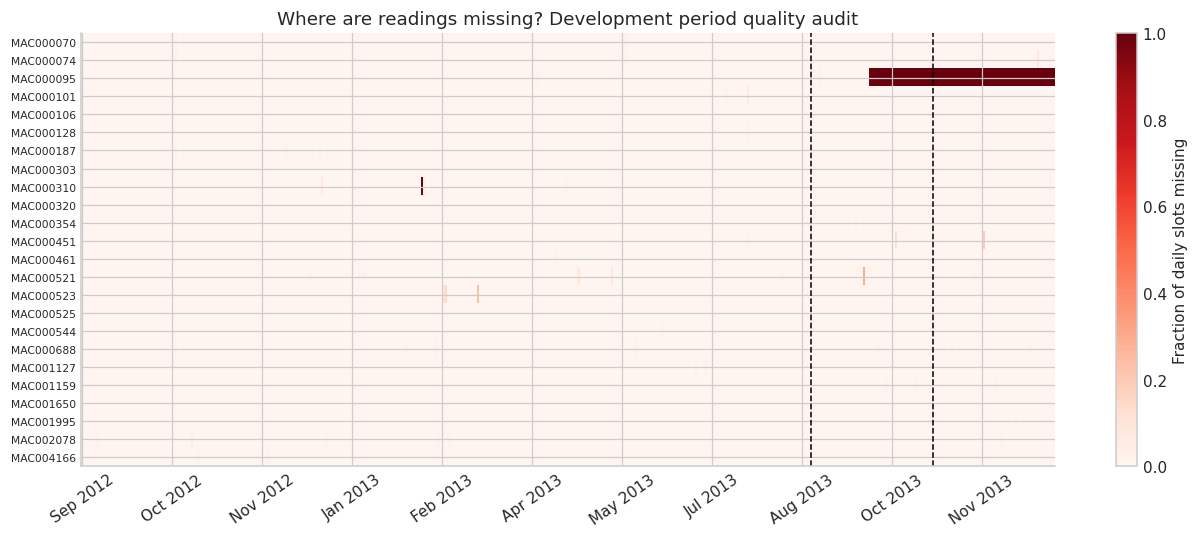

In [14]:
split_quality = []
for name, start, end in [('train', START, VALID_START), ('validation', VALID_START, TEST_START), ('test', TEST_START, END)]:
    part = panel.loc[panel.timestamp.ge(start) & panel.timestamp.lt(end)]
    split_quality.append({'split': name, 'slots': len(part), 'missing': int(part.energy_kwh.isna().sum()), 'coverage': part.energy_kwh.notna().mean()})
split_quality = pd.DataFrame(split_quality)
split_quality.to_csv(REPORTS / 'quality_by_split.csv', index=False)
display(split_quality)

missing = panel.assign(day=panel.timestamp.dt.floor('D'), missing=panel.energy_kwh.isna())
matrix = missing.groupby(['household_id', 'day']).missing.mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(matrix.values, aspect='auto', interpolation='nearest', cmap='Reds', vmin=0, vmax=1)
ticks = np.arange(0, len(matrix.columns), 45)
ax.set_xticks(ticks, [matrix.columns[i].strftime('%b %Y') for i in ticks], rotation=35)
ax.set_yticks(range(len(matrix)), matrix.index, fontsize=7)
for boundary in [VALID_START, TEST_START]:
    ax.axvline((boundary-START).days-.5, color='black', linestyle='--', linewidth=1)
ax.set_title('Where are readings missing? Development period quality audit')
fig.colorbar(im, ax=ax, label='Fraction of daily slots missing')
plt.tight_layout()
plt.savefig(FIGURES / '01_missingness.png', dpi=140, bbox_inches='tight')
plt.show()

Validation and test are inspected only for data coverage here.
Source timestamps have no timezone offset. Keep the source 48-slot clock for this offline project.


## 4. Temporal EDA — training only

Use September 2012 to August 2013 for pattern analysis. Daily totals require all 48 readings, so missing days are not treated as low consumption.


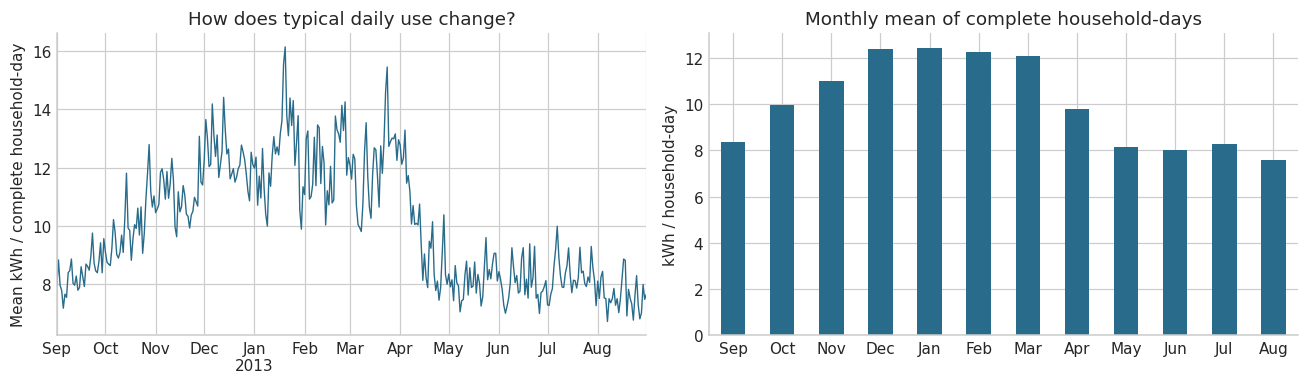

In [15]:
train = panel.loc[panel.timestamp.lt(VALID_START)].copy()
train['slot'] = train.timestamp.dt.hour*2 + train.timestamp.dt.minute//30
train['day_of_week'] = train.timestamp.dt.dayofweek
train['weekend'] = train.day_of_week.ge(5)
daily = train.groupby(['household_id', train.timestamp.dt.floor('D')]).energy_kwh.agg(['count', 'sum'])
daily['complete_day_kwh'] = daily['sum'].where(daily['count'].eq(48))
daily_mean = daily.groupby('timestamp').complete_day_kwh.mean()
monthly = daily.reset_index().groupby(pd.Grouper(key='timestamp', freq='MS')).complete_day_kwh.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
daily_mean.plot(ax=axes[0], color='#286b8a', linewidth=.9)
axes[0].set(title='How does typical daily use change?', xlabel='', ylabel='Mean kWh / complete household-day')
monthly.plot.bar(ax=axes[1], color='#286b8a')
axes[1].set_xticklabels(monthly.index.strftime('%b'), rotation=0)
axes[1].set(title='Monthly mean of complete household-days', xlabel='', ylabel='kWh / household-day')
plt.tight_layout()
plt.savefig(FIGURES / '02_daily_monthly.png', dpi=140, bbox_inches='tight')
plt.show()

Monthly mean use varies from 7.61 to 12.46 kWh per complete household-day.
The full training year shows a seasonal pattern, but consumption alone does not prove a weather effect.


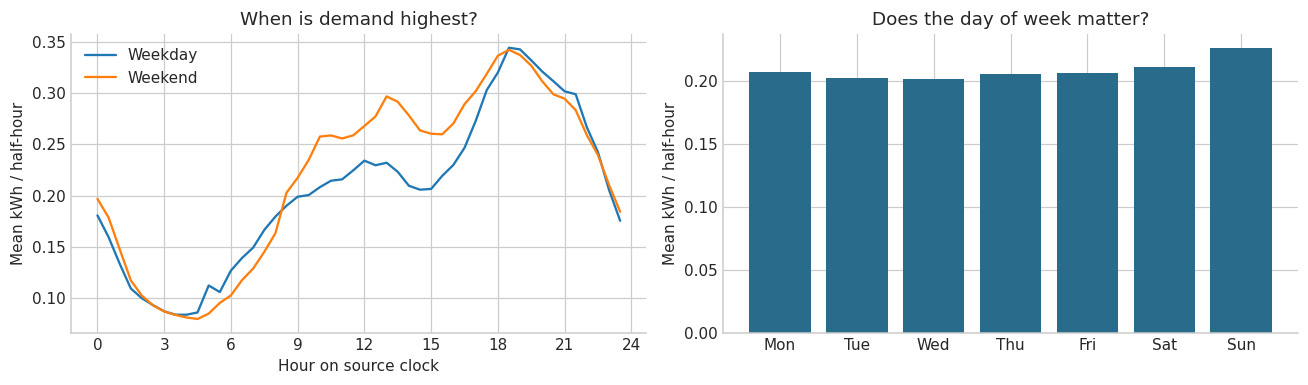

Weekday/weekend means: {False: 0.2048, True: 0.2186}


In [16]:
intraday = train.groupby(['slot', 'weekend']).energy_kwh.mean().unstack()
weekly = train.groupby('day_of_week').energy_kwh.mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for is_weekend, label in [(False, 'Weekday'), (True, 'Weekend')]:
    axes[0].plot(intraday.index/2, intraday[is_weekend], label=label)
axes[0].set(title='When is demand highest?', xlabel='Hour on source clock', ylabel='Mean kWh / half-hour', xticks=range(0, 25, 3))
axes[0].legend()
axes[1].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], weekly, color='#286b8a')
axes[1].set(title='Does the day of week matter?', ylabel='Mean kWh / half-hour')
plt.tight_layout()
plt.savefig(FIGURES / '03_daily_weekly_patterns.png', dpi=140, bbox_inches='tight')
plt.show()
print('Weekday/weekend means:', train.groupby('weekend').energy_kwh.mean().round(4).to_dict())

The average peak is around 18:30 and the minimum around 04:00. Weekend mean use is about 6.8% higher than weekday use.
Keep half-hour resolution and test calendar features separately.


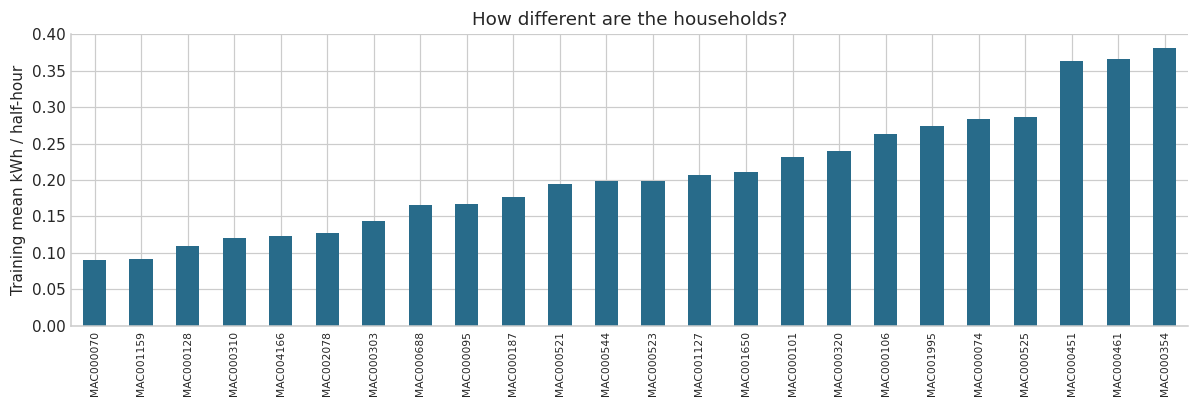

,median household correlation
1,0.6455
48,0.3172
336,0.3481


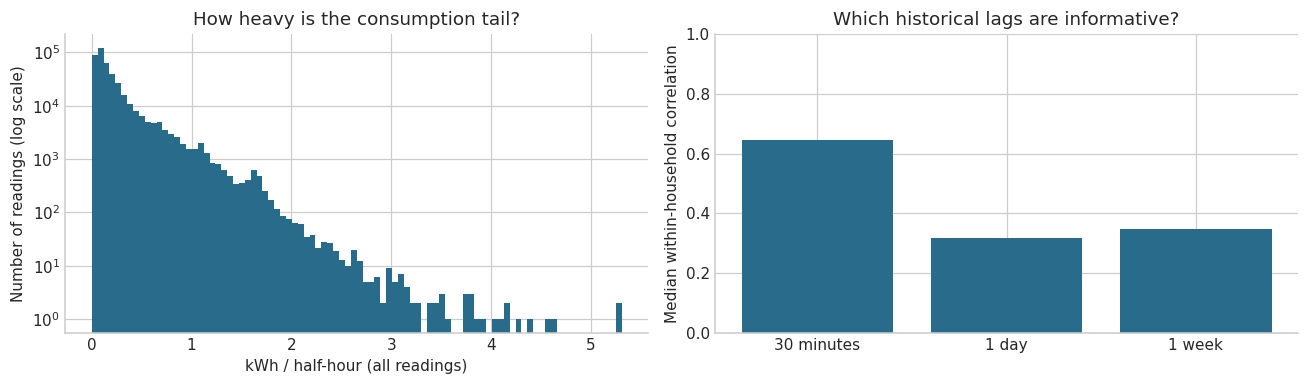

In [17]:
household_means = train.groupby('household_id').energy_kwh.mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 3.8))
household_means.plot.bar(ax=ax, color='#286b8a')
ax.set(title='How different are the households?', xlabel='', ylabel='Training mean kWh / half-hour')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES / '04_household_variation.png', dpi=140, bbox_inches='tight')
plt.show()

wide = train.pivot(index='timestamp', columns='household_id', values='energy_kwh')
lag_correlations = pd.DataFrame({lag: wide.corrwith(wide.shift(lag)) for lag in [1, 48, 336]})
display(lag_correlations.median().rename('median household correlation').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(train.energy_kwh.dropna(), bins=90, color='#286b8a', log=True)
axes[0].set(title='How heavy is the consumption tail?', xlabel='kWh / half-hour (all readings)', ylabel='Number of readings (log scale)')
axes[1].bar(['30 minutes', '1 day', '1 week'], lag_correlations.median(), color='#286b8a')
axes[1].set(title='Which historical lags are informative?', ylabel='Median within-household correlation', ylim=(0, 1))
plt.tight_layout()
plt.savefig(FIGURES / '05_distribution_lags.png', dpi=140, bbox_inches='tight')
plt.show()

Household means range from 0.090 to 0.381 kWh per slot. The median is 0.116 kWh and the 99th percentile is 1.316 kWh.
Use MAE as the main metric and RMSE to show large errors. Keep the right tail.

Median daily and weekly lag correlations are 0.317 and 0.348. Both seasonal baselines are useful references.
The 30-minute lag is stronger, but it is not available for most slots of a midnight forecast.


## 5. Choose the forecasting problem

| Formulation | Benefit | Limitation for this project |
|---|---|---|
| Next 30-minute interval | Simple short-horizon prediction | Limited advance planning for cost optimization |
| A single slot 24 hours ahead | Clear fixed horizon | Does not directly provide a complete daily load profile |
| **Next 24 hours, issued at midnight** | Full profile for daily planning; daily/weekly history available | Requires 48 predictions from the same information cutoff |
| Next daily total | Small dataset and simple evaluation | Loses within-day timing needed for optimization |

**Decision:** at midnight D, predict each household's 48 half-hour kWh values over `[D, D + 1 day)`.
The unit of prediction is one household and one half-hour slot. The output is a 48-value household profile; it is not an aggregate over households.

Assume readings indexed before D are available at D, with no reporting delay. This offline convention must be revisited if meter latency or interval-end labeling is established.
Forecasts support later scenario-based cost analysis; total household load alone does not identify which appliances are flexible.

## 6. Small, origin-safe feature set

- History: the same slot yesterday (`lag_48`) and last week (`lag_336`).
- Calendar: half-hour `slot`, `day_of_week`, and `month`.

No rolling mean is necessary for this first reference. No `lag_1`: later target-day observations would leak into a midnight forecast.
Look up historical values by household and exact timestamp; missing intervals must not shift a lag to the wrong time.

### Start with calendar information

The forecast origin is midnight on the target day. `slot` runs from 0 to 47, so it distinguishes 18:00 from 18:30.
Calendar information is already known at the forecast origin.

In [18]:
features = panel[['household_id', 'timestamp', 'energy_kwh']].copy()
features['forecast_origin'] = features['timestamp'].dt.floor('D')
features['slot'] = features['timestamp'].dt.hour * 2 + features['timestamp'].dt.minute // 30
features['day_of_week'] = features['timestamp'].dt.dayofweek
features['month'] = features['timestamp'].dt.month
display(features.head())

,household_id,timestamp,energy_kwh,forecast_origin,slot,day_of_week,month
0,MAC000070,2012-09-01 00:00:00,0.0120,2012-09-01,0,5,9
1,MAC000070,2012-09-01 00:30:00,0.0400,2012-09-01,1,5,9
2,MAC000070,2012-09-01 01:00:00,0.0020,2012-09-01,2,5,9
3,MAC000070,2012-09-01 01:30:00,0.0040,2012-09-01,3,5,9
4,MAC000070,2012-09-01 02:00:00,0.0380,2012-09-01,4,5,9


### Match yesterday's reading to today's target

For example, the reading at September 1, 18:30 becomes `lag_48` for September 2, 18:30.
Move the historical timestamp forward one day, then join on household and timestamp. An absent reading stays missing.

In [19]:
yesterday = panel[['household_id', 'timestamp', 'energy_kwh']].copy()
yesterday['timestamp'] = yesterday['timestamp'] + pd.Timedelta(days=1)
yesterday = yesterday.rename(columns={'energy_kwh': 'lag_48'})
features = features.merge(yesterday, on=['household_id', 'timestamp'], how='left', validate='one_to_one')

Repeat the same idea with seven days to create `lag_336`. Both historical readings must be earlier than midnight on the target day.

In [20]:
last_week = panel[['household_id', 'timestamp', 'energy_kwh']].copy()
last_week['timestamp'] = last_week['timestamp'] + pd.Timedelta(days=7)
last_week = last_week.rename(columns={'energy_kwh': 'lag_336'})
features = features.merge(last_week, on=['household_id', 'timestamp'], how='left', validate='one_to_one')

assert (features['timestamp'] - pd.Timedelta(days=1) < features['forecast_origin']).all()
assert (features['timestamp'] - pd.Timedelta(days=7) < features['forecast_origin']).all()
display(features.loc[features['forecast_origin'] == VALID_START].head())

,household_id,timestamp,energy_kwh,forecast_origin,slot,day_of_week,month,lag_48,lag_336
17520,MAC000070,2013-09-01 00:00:00,0.0690,2013-09-01,0,6,9,0.0380,0.0430
17521,MAC000070,2013-09-01 00:30:00,0.0130,2013-09-01,1,6,9,0.0220,0.0350
17522,MAC000070,2013-09-01 01:00:00,0.0130,2013-09-01,2,6,9,0.0270,0.0340
17523,MAC000070,2013-09-01 01:30:00,0.0400,2013-09-01,3,6,9,0.0000,0.0370
17524,MAC000070,2013-09-01 02:00:00,0.0370,2013-09-01,4,6,9,0.0000,0.0870


## 7. Chronological evaluation protocol

| Split | Target dates | Purpose |
|---|---|---|
| Train | 2012-09-01 to 2013-08-31 | Household selection, EDA and model training |
| Validation | 2013-09-01 to 2013-10-31 | Model comparison |
| Test | 2013-11-01 to 2013-12-31 | Final evaluation after choices are fixed |

Use the same households in all splits. Each day is forecast at midnight. Past observations can be used for later days.
There is no random split, future filling or use of target-day readings.


In [21]:
features['split'] = 'train'
features.loc[features['forecast_origin'] >= VALID_START, 'split'] = 'validation'
features.loc[features['forecast_origin'] >= TEST_START, 'split'] = 'test'

# A shared mask makes the two baselines comparable on exactly the same targets.
required_values = ['energy_kwh', 'lag_48', 'lag_336']
features['evaluation_eligible'] = features[required_values].notna().all(axis=1)
features.to_parquet(PROCESSED / 'forecast_features.parquet', index=False)

split_summary = features.groupby('split', sort=False).agg(
    first_target=('timestamp', 'min'), last_target=('timestamp', 'max'),
    households=('household_id', 'nunique'), rows=('timestamp', 'size'))
display(split_summary)
print('Complete training examples:', features.loc[features['split'] == 'train', 'evaluation_eligible'].sum())

,first_target,last_target,households,rows
split,,,,
train,2012-09-01,2013-08-31 23:30:00,24,420480
validation,2013-09-01,2013-10-31 23:30:00,24,70272
test,2013-11-01,2013-12-31 23:30:00,24,70272


Complete training examples: 412051


## 8. Validation baselines

Daily naive repeats yesterday's 48 slots; weekly naive repeats last week's corresponding day.
Score both on the same rows with an observed target and both historical values available. No missing target is imputed.
MAE and RMSE are measured in kWh per household half-hour. Pooled MAE weights each scored slot equally; household means are also saved.

### Calculate one baseline first

Daily naive uses `lag_48` as its prediction. The error is prediction minus observed consumption.
MAE averages the absolute errors. RMSE squares the errors before averaging, so it gives more weight to large misses.

In [22]:
validation = features.loc[features['split'] == 'validation'].copy()
common = validation.loc[validation['evaluation_eligible']].copy()
error = common['lag_48'] - common['energy_kwh']
mae = error.abs().mean()
rmse = np.sqrt((error ** 2).mean())
print(f'Daily naive: MAE = {mae:.6f}, RMSE = {rmse:.6f} kWh')

Daily naive: MAE = 0.111875, RMSE = 0.219287 kWh


Now repeat those calculations for both baselines. Use a small loop to build the comparison table.
The shared mask is used only for scoring; it is not a model feature.

In [23]:
baselines = {'Daily seasonal naive': 'lag_48', 'Weekly seasonal naive': 'lag_336'}
results = []
observed_targets = validation['energy_kwh'].notna().sum()
for name, column in baselines.items():
    error = common[column] - common['energy_kwh']
    results.append({
        'baseline': name,
        'mae_kwh': error.abs().mean(),
        'rmse_kwh': np.sqrt((error ** 2).mean()),
        'scored_slots': len(common),
        'total_slots': len(validation),
        'observed_targets': observed_targets,
        'coverage_all_slots': len(common) / len(validation),
        'coverage_observed_targets': len(common) / observed_targets,
    })
scores = pd.DataFrame(results)
scores.to_csv(REPORTS / 'baseline_metrics.csv', index=False)
display(scores)

,baseline,mae_kwh,rmse_kwh,scored_slots,total_slots,observed_targets,coverage_all_slots,coverage_observed_targets
0,Daily seasonal naive,0.1119,0.2193,68659,70272,68711,0.9770,0.9992
1,Weekly seasonal naive,0.1095,0.2135,68659,70272,68711,0.9770,0.9992


### Check coverage and household differences

Save household-level errors as well. Their average gives each household equal weight, even when a household has fewer observed targets.

In [24]:
household_results = []
availability_rows = []
for name, column in baselines.items():
    for household, data in common.groupby('household_id'):
        error = data[column] - data['energy_kwh']
        household_results.append({'baseline': name, 'household_id': household, 'slots': len(data),
                                  'mae_kwh': error.abs().mean(), 'rmse_kwh': np.sqrt((error ** 2).mean())})
    available = validation['energy_kwh'].notna() & validation[column].notna()
    availability_rows.append({'baseline': name, 'predictions_available': validation[column].notna().sum(),
                              'independently_scorable_slots': available.sum(), 'common_scorable_slots': len(common)})

household_scores = pd.DataFrame(household_results)
availability = pd.DataFrame(availability_rows)
household_scores.to_csv(REPORTS / 'baseline_metrics_by_household.csv', index=False)
availability.to_csv(REPORTS / 'baseline_availability.csv', index=False)
display(availability)
display(household_scores.groupby('baseline')['mae_kwh'].mean().to_frame('household_macro_MAE_kWh'))
display(validation.groupby('household_id').agg(observed=('energy_kwh', 'count'), scored=('evaluation_eligible', 'sum')).sort_values('observed').head(3))

,baseline,predictions_available,independently_scorable_slots,common_scorable_slots
0,Daily seasonal naive,68759,68685,68659
1,Weekly seasonal naive,69047,68685,68659


,household_macro_MAE_kWh
baseline,
Daily seasonal naive,0.1102
Weekly seasonal naive,0.1084


,observed,scored
household_id,,
MAC000095,1392,1390
MAC000521,2914,2885
MAC000451,2922,2910


Weekly naive is slightly better: **MAE 0.10951**, RMSE 0.21351 kWh. Daily naive gives **MAE 0.11188**, RMSE 0.21929 kWh.
Both score 68,659 of 70,272 planned slots. The test set stays unscored in this notebook.


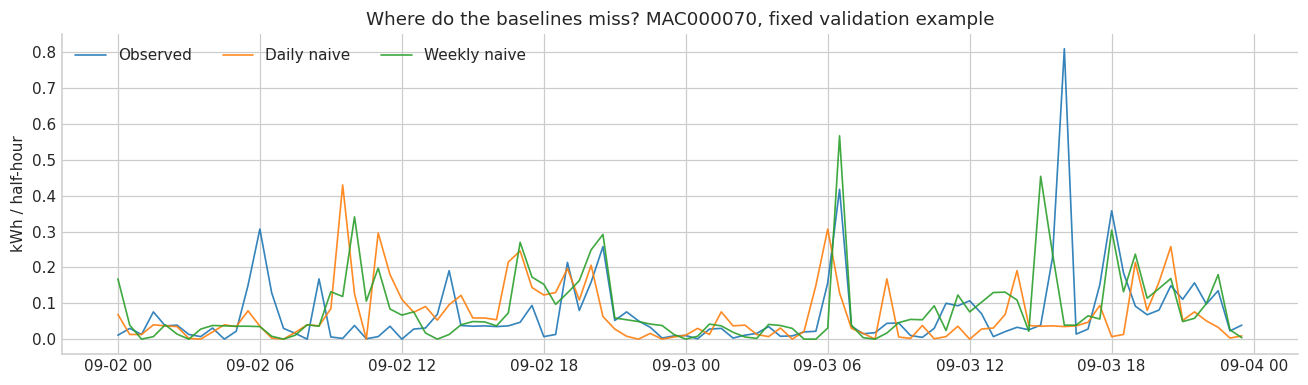

In [25]:
# A fixed example: first selected household, first two full weekdays in validation.
example_id = sorted(panel.household_id.unique())[0]
example = validation.loc[validation.household_id.eq(example_id) & validation.timestamp.ge('2013-09-02') & validation.timestamp.lt('2013-09-04')]
fig, ax = plt.subplots(figsize=(12, 3.6))
for column, label in [('energy_kwh', 'Observed'), ('lag_48', 'Daily naive'), ('lag_336', 'Weekly naive')]:
    ax.plot(example.timestamp, example[column], label=label, linewidth=1.1, alpha=.9)
ax.set(title=f'Where do the baselines miss? {example_id}, fixed validation example', ylabel='kWh / half-hour', xlabel='')
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig(FIGURES / '06_baseline_example.png', dpi=140, bbox_inches='tight')
plt.show()

Seasonal repetition is a useful reference, but sudden peaks and changes in routine remain difficult.
The comparison table gives the reference score.

## Next step: Forecasting Models

Keep the target, households, split dates and validation mask fixed.
Compare history features, then calendar features, using the same model and rows. Weather must be tested separately and clearly labeled if future observed values are used.

Keep high readings and missing values. No learned model, anomaly detector, optimizer or application is built in this exploration step.


## From exploration to reusable code

The steps above come first. When the logic is clear, the same operations can be grouped into functions:

- `src/data/preprocessing.py`: reading, cleaning and household selection.
- `src/data/features.py`: calendar fields, exact historical matches and date splits.
- `src/evaluation.py`: common-row baseline scores.

These modules support repeatable scripts and tests. The notebook stays readable on its own and does not import them.